In [1]:
import pandas as pd
import plotly.express as px

# Exercise

Now that we have learned some of the basics of python, we should practice how to use this new superpower. We have here prepared a loosely guided exercise that focusses on data exploration and visualization on two example datasets, one on strokes and one on cirrhosis. You can also explore a dataset of your choosing, though the questions are prepared with the example datasets in mind.

Here you can see the [metadata](https://www.kaggle.com/datasets/fedesoriano/cirrhosis-prediction-dataset) for the cirrhosis dataset which describes what each of the columns are. For the stroke data the meaning of the columns is more straightforward.

## 1. Data Loading

We will start with the **stroke** dataset. You can find it on the GitHub repository under Exercise/datasets. Load the stroke data into colab by using one of the two approaches detailed below and assign it to variable name ```data```.

### 1.1 Loading the data

**Option 1:**

Use the pandas csv reader with a link to the data on GitHub. To do this, go to the github repository, find the stroke dataset and click on the 'raw' button. Copy that link and enter it as the file path in pandas csv reader.

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/Center-for-Health-Data-Science/PythonTsunami/refs/heads/2024_Oct/Exercise/datasets/healthcare-dataset-stroke-data.csv")
df.head()



,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


... or

**Option 2**

Manually load the dataset into colab and then read it with the pandas csv reader. See steps below:

1. go to the left side bar and click on the folder icon
2. click on data upload
3. select dataset from your computer
4. call pandas csv reader with the name of the dataset

### 1.2 First look

Have a first look at the data. There are some neat built-in pandas functions to get an initial understanding of the data, i.e. by using the info function: `df.info()`, or the use pandas `df.describe()` function.

Questions you might want to answer here:
- What different types of columns do you have?
- Is there a column that describes a variable that can be understood as an 'outcome' ? Which one?
- How many values does each variable, i.e. column, have and what are some preliminary statistics of the features? (tip: use pandas `describe` function)



In [5]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


It helps to know which column is the outcome variable. In the stroke datasets (and many others!) the outcome variable is coded as a numerical variable. However, during analysis it should be interpreted as categorical.

Identify the column of the outcome variable and change its type to "category" by using `astype()`. You can see an example in the [API reference on categorical data](https://pandas.pydata.org/pandas-docs/stable/user_guide/categorical.html). Remember to save your changes!

Then, use `info()` on the dataframe again. Has it changed?

In [6]:
df['stroke'] = df['stroke'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 5110 non-null   int64   
 1   gender             5110 non-null   object  
 2   age                5110 non-null   float64 
 3   hypertension       5110 non-null   int64   
 4   heart_disease      5110 non-null   int64   
 5   ever_married       5110 non-null   object  
 6   work_type          5110 non-null   object  
 7   Residence_type     5110 non-null   object  
 8   avg_glucose_level  5110 non-null   float64 
 9   bmi                4909 non-null   float64 
 10  smoking_status     5110 non-null   object  
 11  stroke             5110 non-null   category
dtypes: category(1), float64(3), int64(3), object(5)
memory usage: 444.4+ KB


## 2. Exploratory analysis

Get to know your data better. If you want to first visually inspect the data it can help to explore with some plots.


### 2.1 Violin plots and histograms

Consider you dataframe columns that are not the outcome variable. How are the measurements distributed?

To study the distributions we want to make **violin plots** of variables, i.e. data columns, that are numeric and **histograms** of the variables that are strings/categorical.

To check for the data type of a column, have a look at how data types are specified in `dataframe.dtypes`. Then check the data type of each column. Remember a column is a **pandas `Series`**, so it has a `dtype` attribute instead (only dataframes have `dtypes`!).

You can start by figuring out how to make a plot of the data in one column. Once you have that, make one plot for each column that is numeric or a string (except the outcome). This is a repetitive task, so it is ideally suited for a loop. Remember to use `fig.show()` to actually display your plots during the loop.

**Pro version**: Some columns are not actually explanatory variables, such as a the ID column. You can identify these columns i.e. by seeing that each of their values is unique (this would be very unlikely for a measured variable). Skip them when making the plots.


In [11]:
# violin plots of all columns with numeric data (make a seperate plot for each column)
for col in df.columns:
    if df[col].dtype == 'float64' or df[col].dtype == 'int64':
        fig = px.violin(df, y=col, box=True, points="all")
        fig.show()


In [17]:
# convert data type for hypertension and heart_disease to categorical

df['hypertension'] = df['hypertension'].astype('category')
df['heart_disease'] = df['heart_disease'].astype('category')

# develop a seperate histogram for hypertension, stroke, and heart disease
for col in df.columns:
    if df[col].dtype == 'category':
        fig = px.histogram(df, x=col)
        fig.show()




In [18]:
# develop a seperate histogram for each column with either stringe
for col in df.columns:
    if df[col].dtype == 'object':
        fig = px.histogram(df, x=col)
        fig.show()

In [19]:
# To check for the data type of a column, have a look at how data types are specified in dataframe.dtypes. Then check the data type of each column. Remember a column is a pandas Series, so it has a dtype attribute instead (only dataframes have dtypes!).
# data types
df.dtypes

,0
id,int64
gender,object
age,float64
hypertension,category
heart_disease,category
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64


### 2.2 Correlation coefficients

Plot the correlation coefficients of all numerical features:

1. Use the method `corr()` on the dataframe. What is the result?

2. Now use a heatmap to show the correlation coeffcients graphically.

3. Try some different options to make your heatmap look nicer.

In [20]:
# Plot the correlation coefficients of all numerical features:
df  = df.select_dtypes(include=['float64', 'int64'])
df.corr()




,id,age,avg_glucose_level,bmi
id,1.000000,0.003538,0.001092,0.003084
age,0.003538,1.000000,0.238171,0.333398
avg_glucose_level,0.001092,0.238171,1.000000,0.175502
bmi,0.003084,0.333398,0.175502,1.000000


In [21]:
# Use the method corr() on the dataframe. What is the results.
df.corr().style.background_gradient(cmap='coolwarm')


,id,age,avg_glucose_level,bmi
id,1.000000,0.003538,0.001092,0.003084
age,0.003538,1.000000,0.238171,0.333398
avg_glucose_level,0.001092,0.238171,1.000000,0.175502
bmi,0.003084,0.333398,0.175502,1.000000


In [23]:
# develop a heatmap to show the correlation coeffcients graphically.
fig = px.imshow(df.corr())
fig.show()

In [24]:
# Try some different options to make your heatmap look nicer.
fig = px.imshow(df.corr(), color_continuous_scale='RdBu')
fig.show()

### 2.3 Scatter plot

Make a scatter plot of the two variables with the highest correlation. Divide the plots by the outcome variable and add marginal plots and a trendline:

1. Find the pair of variables that has the highest correlation with each other and make a scatter plot of them.

2. Divide the scatter plot into two by the outcome variable. Have a look at ``facet`` and the visualization lecture if you have trouble.

3. Add marginal distributions on one of the axis and a trendline.

<Axes: xlabel='avg_glucose_level', ylabel='bmi'>

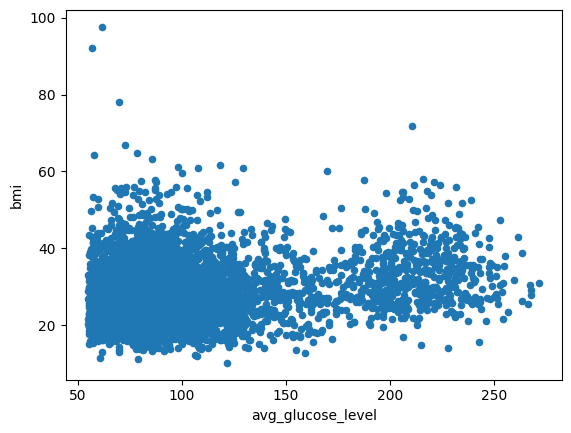

In [31]:
# Make a scatter plot of the two variables with the highest correlation.
df.plot.scatter(x='avg_glucose_level', y='bmi')

In [32]:
# Divide the scatter plot into two by the outcome variable. Have a look at facet and the visualization lecture if you have trouble.
# Divide the plots by the outcome variable and add marginal plots and a trendline:
fig = px.scatter(df, x="avg_glucose_level", y="bmi")
fig.show()



In [34]:
# Add marginal distributions on one of the axis and a trendline.
fig = px.scatter(df, x="avg_glucose_level", y="bmi", marginal_x="box", marginal_y="violin")
fig.show()
# trendline
fig = px.scatter(df, x="avg_glucose_level", y="bmi", trendline="ols")
fig.show()


## 3. Data cleaning

Now, we switch the [cirrhosis dataset]('https://raw.githubusercontent.com/Center-for-Health-Data-Science/PythonTsunami/spring2022/Exercise/datasets/cirrhosis.csv').

We will investigate what data is missing and try to impute it.

A word of caution:

Note that imputation is a __complex subject__ and whether it makes sense to do it and the method used highly depend on the data set. Sometimes, the mean of a value across all non-missing observations is a good approximation for the missing value. On the other hand, if you have a column that says whether or not the person was treated with the drug or the placebo we have no good way to guess which treatment the person received. Replacing missing values in this column with the most common value (which is that they did get the drug) will produce extremely __wrong data__ and lead you to __wrong conclusions__. Do not do that!


### 3.0 Load the data

Load in the cirrhosis dataset using one of the two methods you used earlier for the stroke data. Change as well the outcome variable to a type "category".

In [35]:
df = pd.read_csv("https://raw.githubusercontent.com/Center-for-Health-Data-Science/PythonTsunami/refs/heads/2024_Oct/Exercise/datasets/cirrhosis.csv")
df


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,414,681,D,NaN,24472,F,NaN,NaN,NaN,N,1.2,NaN,2.96,NaN,NaN,NaN,NaN,174.0,10.9,3.0
414,415,1103,C,NaN,14245,F,NaN,NaN,NaN,N,0.9,NaN,3.83,NaN,NaN,NaN,NaN,180.0,11.2,4.0
415,416,1055,C,NaN,20819,F,NaN,NaN,NaN,N,1.6,NaN,3.42,NaN,NaN,NaN,NaN,143.0,9.9,3.0
416,417,691,C,NaN,21185,F,NaN,NaN,NaN,N,0.8,NaN,3.75,NaN,NaN,NaN,NaN,269.0,10.4,3.0


### 3.1 Missing data

1. Use the pandas method `isnull`.

2. Get the number of missing values per column by calling `sum()` on the result of `isnull`. Which features, i.e. columns have missing values?

3. Make a barplot that shows the number of missing values per column.


In [39]:
# Missing data: Use the pandas method isnull.
df.isnull()


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,False,False,False,True,False,False,True,True,True,False,False,True,False,True,True,True,True,False,False,False
414,False,False,False,True,False,False,True,True,True,False,False,True,False,True,True,True,True,False,False,False
415,False,False,False,True,False,False,True,True,True,False,False,True,False,True,True,True,True,False,False,False
416,False,False,False,True,False,False,True,True,True,False,False,True,False,True,True,True,True,False,False,False


In [38]:
# Get the number of missing values per column by calling sum() on the result of isnull. Which features, i.e. columns have missing values?
df.isnull().sum()

# Make a barplot that shows the number of missing values per column.
fig = px.bar(df.isnull().sum())
fig.show()


### 3.2 Omitting observations with missing values

1. Create a subset in which you omit all patients, i.e. rows, which have missing values in any column. Take care to not overwrite the original dataframe. If you did, you can re-import it.

2. How many observations, i.e. patients, would you be left with if you removed all missing values?

3. How many if you only omit patients where the outcome is missing?


In [40]:
# Create a subset in which you omit all patients, i.e. rows, which have missing values in any column. Take care to not overwrite the original dataframe. If you did, you can re-import it.
df_subset = df.dropna()
df_subset

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,308,1153,C,D-penicillamine,22347,F,N,Y,N,N,0.4,246.0,3.58,24.0,797.0,91.00,113.0,288.0,10.4,2.0
308,309,994,C,Placebo,21294,F,N,N,N,N,0.4,260.0,2.75,41.0,1166.0,70.00,82.0,231.0,10.8,2.0
309,310,939,C,D-penicillamine,22767,F,N,N,N,N,1.7,434.0,3.35,39.0,1713.0,171.00,100.0,234.0,10.2,2.0
310,311,839,C,D-penicillamine,13879,F,N,N,N,N,2.0,247.0,3.16,69.0,1050.0,117.00,88.0,335.0,10.5,2.0


In [41]:
# How many observations, i.e. patients, would you be left with if you removed all missing values?
df_subset.shape

(276, 20)

In [42]:
# # How many if you only omit patients where the outcome is missing?
df_subset = df.dropna(subset=['Stage'])
df_subset

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,414,681,D,NaN,24472,F,NaN,NaN,NaN,N,1.2,NaN,2.96,NaN,NaN,NaN,NaN,174.0,10.9,3.0
414,415,1103,C,NaN,14245,F,NaN,NaN,NaN,N,0.9,NaN,3.83,NaN,NaN,NaN,NaN,180.0,11.2,4.0
415,416,1055,C,NaN,20819,F,NaN,NaN,NaN,N,1.6,NaN,3.42,NaN,NaN,NaN,NaN,143.0,9.9,3.0
416,417,691,C,NaN,21185,F,NaN,NaN,NaN,N,0.8,NaN,3.75,NaN,NaN,NaN,NaN,269.0,10.4,3.0


### 3.3 Effects of removing data

We can now have a look at how removing nans effects the data.


1. First, plot the correlation coefficient between all numerical columns in the original cirrhosis dataframe. (Analogous to 2.2).

2. Now, remake the plot for the subset where you have removed all rows with any missing data. Have the correlations changed?

In [44]:
# plot the correlation coefficient between all numerical columns in the original cirrhosis dataframe. (Analogous to 2.2).
df  = df.select_dtypes(include=['float64', 'int64'])
df.corr()

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
ID,1.000000,-0.354305,0.037136,-0.062154,0.032897,-0.128924,-0.098663,-0.352856,-0.012097,-0.034100,-0.076699,-0.191930,-0.033757
N_Days,-0.354305,1.000000,-0.125934,-0.403953,-0.138236,0.430829,-0.364809,0.149269,-0.225492,-0.153000,0.151361,-0.111470,-0.366193
Age,0.037136,-0.125934,1.000000,0.002362,-0.157620,-0.182350,0.061549,-0.047247,-0.149869,0.022065,-0.148201,0.113760,0.189083
Bilirubin,-0.062154,-0.403953,0.002362,1.000000,0.397129,-0.314177,0.456918,0.116984,0.441730,0.436748,-0.013435,0.314894,0.200731
Cholesterol,0.032897,-0.138236,-0.157620,0.397129,1.000000,-0.069733,0.126115,0.149473,0.353246,0.276830,0.191710,-0.030811,0.011164
Albumin,-0.128924,0.430829,-0.182350,-0.314177,-0.069733,1.000000,-0.264771,-0.101456,-0.220047,-0.103417,0.158659,-0.200592,-0.305296
Copper,-0.098663,-0.364809,0.061549,0.456918,0.126115,-0.264771,1.000000,0.187357,0.293829,0.279852,-0.064403,0.218224,0.269400
Alk_Phos,-0.352856,0.149269,-0.047247,0.116984,0.149473,-0.101456,0.187357,1.000000,0.112217,0.180082,0.143733,0.089384,0.041273
SGOT,-0.012097,-0.225492,-0.149869,0.441730,0.353246,-0.220047,0.293829,0.112217,1.000000,0.126119,-0.120147,0.112174,0.164945
Tryglicerides,-0.034100,-0.153000,0.022065,0.436748,0.276830,-0.103417,0.279852,0.180082,0.126119,1.000000,0.103212,0.020122,0.123899


In [45]:
# Now, remake the plot for the subset where you have removed all rows with any missing data. Have the correlations changed?
df_subset  = df_subset.select_dtypes(include=['float64', 'int64'])
df_subset.corr()

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
ID,1.000000,-0.361034,0.028863,-0.061492,0.032897,-0.125524,-0.098663,-0.352856,-0.012097,-0.034100,-0.089686,-0.192291,-0.033757
N_Days,-0.361034,1.000000,-0.135844,-0.400692,-0.138236,0.438433,-0.364809,0.149269,-0.225492,-0.153000,0.169242,-0.109935,-0.366193
Age,0.028863,-0.135844,1.000000,0.006288,-0.157620,-0.182836,0.061549,-0.047247,-0.149869,0.022065,-0.158195,0.115933,0.189083
Bilirubin,-0.061492,-0.400692,0.006288,1.000000,0.397129,-0.318619,0.456918,0.116984,0.441730,0.436748,-0.024845,0.313184,0.200731
Cholesterol,0.032897,-0.138236,-0.157620,0.397129,1.000000,-0.069733,0.126115,0.149473,0.353246,0.276830,0.191710,-0.030811,0.011164
Albumin,-0.125524,0.438433,-0.182836,-0.318619,-0.069733,1.000000,-0.264771,-0.101456,-0.220047,-0.103417,0.167703,-0.207897,-0.305296
Copper,-0.098663,-0.364809,0.061549,0.456918,0.126115,-0.264771,1.000000,0.187357,0.293829,0.279852,-0.064403,0.218224,0.269400
Alk_Phos,-0.352856,0.149269,-0.047247,0.116984,0.149473,-0.101456,0.187357,1.000000,0.112217,0.180082,0.143733,0.089384,0.041273
SGOT,-0.012097,-0.225492,-0.149869,0.441730,0.353246,-0.220047,0.293829,0.112217,1.000000,0.126119,-0.120147,0.112174,0.164945
Tryglicerides,-0.034100,-0.153000,0.022065,0.436748,0.276830,-0.103417,0.279852,0.180082,0.126119,1.000000,0.103212,0.020122,0.123899


### 3.4 Imputation

Use the method `fillna()` to impute missing values in the columns **where it makes sense**. Have a look at the documentation: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.fillna.html

1. A good way to impute numerical data can be i.e. the mean or median. Calculate the mean for all numerical columns.

2. Perform the imputation.

3. Re-make the barplot from 3.1. to check that it worked.

4. Recalculate correlation coefficients between all numerical columns and show it in a heatmap.


In [46]:
#  Calculate the mean for all numerical columns.
df.mean()

,0
ID,209.500000
N_Days,1917.782297
Age,18533.351675
Bilirubin,3.220813
Cholesterol,369.510563
Albumin,3.497440
Copper,97.648387
Alk_Phos,1982.655769
SGOT,122.556346
Tryglicerides,124.702128


In [47]:
# Use the method fillna() to impute missing values in the columns where it makes sense. use the means to replace missing values
df.fillna(df.mean())

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,21464,14.5,261.000000,2.60,156.000000,1718.000000,137.950000,172.000000,190.0,12.2,4.0
1,2,4500,20617,1.1,302.000000,4.14,54.000000,7394.800000,113.520000,88.000000,221.0,10.6,3.0
2,3,1012,25594,1.4,176.000000,3.48,210.000000,516.000000,96.100000,55.000000,151.0,12.0,4.0
3,4,1925,19994,1.8,244.000000,2.54,64.000000,6121.800000,60.630000,92.000000,183.0,10.3,4.0
4,5,1504,13918,3.4,279.000000,3.53,143.000000,671.000000,113.150000,72.000000,136.0,10.9,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,414,681,24472,1.2,369.510563,2.96,97.648387,1982.655769,122.556346,124.702128,174.0,10.9,3.0
414,415,1103,14245,0.9,369.510563,3.83,97.648387,1982.655769,122.556346,124.702128,180.0,11.2,4.0
415,416,1055,20819,1.6,369.510563,3.42,97.648387,1982.655769,122.556346,124.702128,143.0,9.9,3.0
416,417,691,21185,0.8,369.510563,3.75,97.648387,1982.655769,122.556346,124.702128,269.0,10.4,3.0


In [48]:
# 3. Re-make the barplot from 3.1. to check that it worked.
fig = px.bar(df.isnull().sum())
fig.show()

In [49]:
# 4. Recalculate correlation coefficients between all numerical columns and show it in a heatmap.
df  = df.select_dtypes(include=['float64', 'int64'])
df.corr()

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
ID,1.000000,-0.354305,0.037136,-0.062154,0.032897,-0.128924,-0.098663,-0.352856,-0.012097,-0.034100,-0.076699,-0.191930,-0.033757
N_Days,-0.354305,1.000000,-0.125934,-0.403953,-0.138236,0.430829,-0.364809,0.149269,-0.225492,-0.153000,0.151361,-0.111470,-0.366193
Age,0.037136,-0.125934,1.000000,0.002362,-0.157620,-0.182350,0.061549,-0.047247,-0.149869,0.022065,-0.148201,0.113760,0.189083
Bilirubin,-0.062154,-0.403953,0.002362,1.000000,0.397129,-0.314177,0.456918,0.116984,0.441730,0.436748,-0.013435,0.314894,0.200731
Cholesterol,0.032897,-0.138236,-0.157620,0.397129,1.000000,-0.069733,0.126115,0.149473,0.353246,0.276830,0.191710,-0.030811,0.011164
Albumin,-0.128924,0.430829,-0.182350,-0.314177,-0.069733,1.000000,-0.264771,-0.101456,-0.220047,-0.103417,0.158659,-0.200592,-0.305296
Copper,-0.098663,-0.364809,0.061549,0.456918,0.126115,-0.264771,1.000000,0.187357,0.293829,0.279852,-0.064403,0.218224,0.269400
Alk_Phos,-0.352856,0.149269,-0.047247,0.116984,0.149473,-0.101456,0.187357,1.000000,0.112217,0.180082,0.143733,0.089384,0.041273
SGOT,-0.012097,-0.225492,-0.149869,0.441730,0.353246,-0.220047,0.293829,0.112217,1.000000,0.126119,-0.120147,0.112174,0.164945
Tryglicerides,-0.034100,-0.153000,0.022065,0.436748,0.276830,-0.103417,0.279852,0.180082,0.126119,1.000000,0.103212,0.020122,0.123899
